# Hampel Despike Synthetic Demo

This notebook reproduces the `hampel_despike(...)` logic used in `Apollo12_LM_Impact_Trace.ipynb` and applies it to synthetic data with several glitch types.

The goal is to make the two key parameters intuitive:

- `window_samples`: half-window size. The full rolling window is `2 * window_samples + 1` samples.
- `n_sigma`: detection threshold. Smaller values are more aggressive; larger values are more conservative.

Injected glitch types:

- single-sample positive spike
- single-sample negative spike
- two-sample burst
- three-sample burst
- broad pulse
- step offset

Expectation: Hampel filtering is best for isolated spikes. It is not meant to remove broad pulses or real step-like waveform changes.


In [12]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


@dataclass
class SimpleTrace:
    data: np.ndarray


def hampel_despike(trace, window_samples=5, n_sigma=6.0):
    """Replace isolated impulsive spikes using a rolling median/MAD test."""

    data = np.asarray(trace.data, dtype=float)
    if np.ma.isMaskedArray(trace.data):
        data = trace.data.filled(np.nan).astype(float)

    series = pd.Series(data)
    width = 2 * window_samples + 1
    rolling_median = series.rolling(width, center=True, min_periods=1).median()
    abs_dev = (series - rolling_median).abs()
    mad = abs_dev.rolling(width, center=True, min_periods=1).median()
    sigma = 1.4826 * mad

    spike_mask = (abs_dev > n_sigma * sigma) & sigma.notna() & (sigma > 0)
    cleaned = series.copy()
    cleaned.loc[spike_mask] = rolling_median.loc[spike_mask]

    trace.data = cleaned.to_numpy(dtype=float)
    return spike_mask.to_numpy(dtype=bool)


In [13]:
def build_synthetic_trace(npts=900, seed=12):
    rng = np.random.default_rng(seed)
    t = np.arange(npts, dtype=float)
    base = (
        0.18 * np.sin(2 * np.pi * t / 90.0)
        + 0.08 * np.sin(2 * np.pi * t / 24.0)
        + 0.03 * rng.standard_normal(npts)
    )
    data = base.copy()

    glitches = [
        {"label": "single_positive", "indices": np.array([120]), "delta": np.array([1.35])},
        {"label": "single_negative", "indices": np.array([220]), "delta": np.array([-1.45])},
        {"label": "doublet", "indices": np.array([320, 321]), "delta": np.array([0.95, 0.85])},
        {"label": "triple_burst", "indices": np.array([470, 471, 472]), "delta": np.array([0.85, -1.05, 0.9])},
        {
            "label": "broad_pulse",
            "indices": np.arange(620, 629),
            "delta": np.array([0.0, 0.2, 0.4, 0.7, 1.0, 0.7, 0.4, 0.2, 0.0]),
        },
        {"label": "step_offset", "indices": np.arange(760, 840), "delta": np.full(80, 0.25)},
    ]

    for glitch in glitches:
        data[glitch["indices"]] += glitch["delta"]

    return t, base, data, glitches


def summarize_detection(mask, glitches):
    rows = []
    for glitch in glitches:
        indices = glitch["indices"]
        hit_count = int(mask[indices].sum())
        rows.append(
            {
                "glitch": glitch["label"],
                "glitch_len": int(len(indices)),
                "flagged_in_glitch": hit_count,
                "fraction_flagged": float(hit_count / len(indices)),
            }
        )
    return pd.DataFrame(rows)


t, base, noisy, glitches = build_synthetic_trace()
configs = [
    {"window_samples": 3, "n_sigma": 2.0},
    {"window_samples": 9, "n_sigma": 2.0},
    {"window_samples": 9, "n_sigma": 4.0},
    {"window_samples": 20, "n_sigma": 2.0},
    {"window_samples": 20, "n_sigma": 6.0},
    {"window_samples": 3, "n_sigma": 6.0},


]

pd.DataFrame(configs)


,window_samples,n_sigma
0,3,2.0
1,9,2.0
2,9,4.0
3,20,2.0
4,20,6.0
5,3,6.0


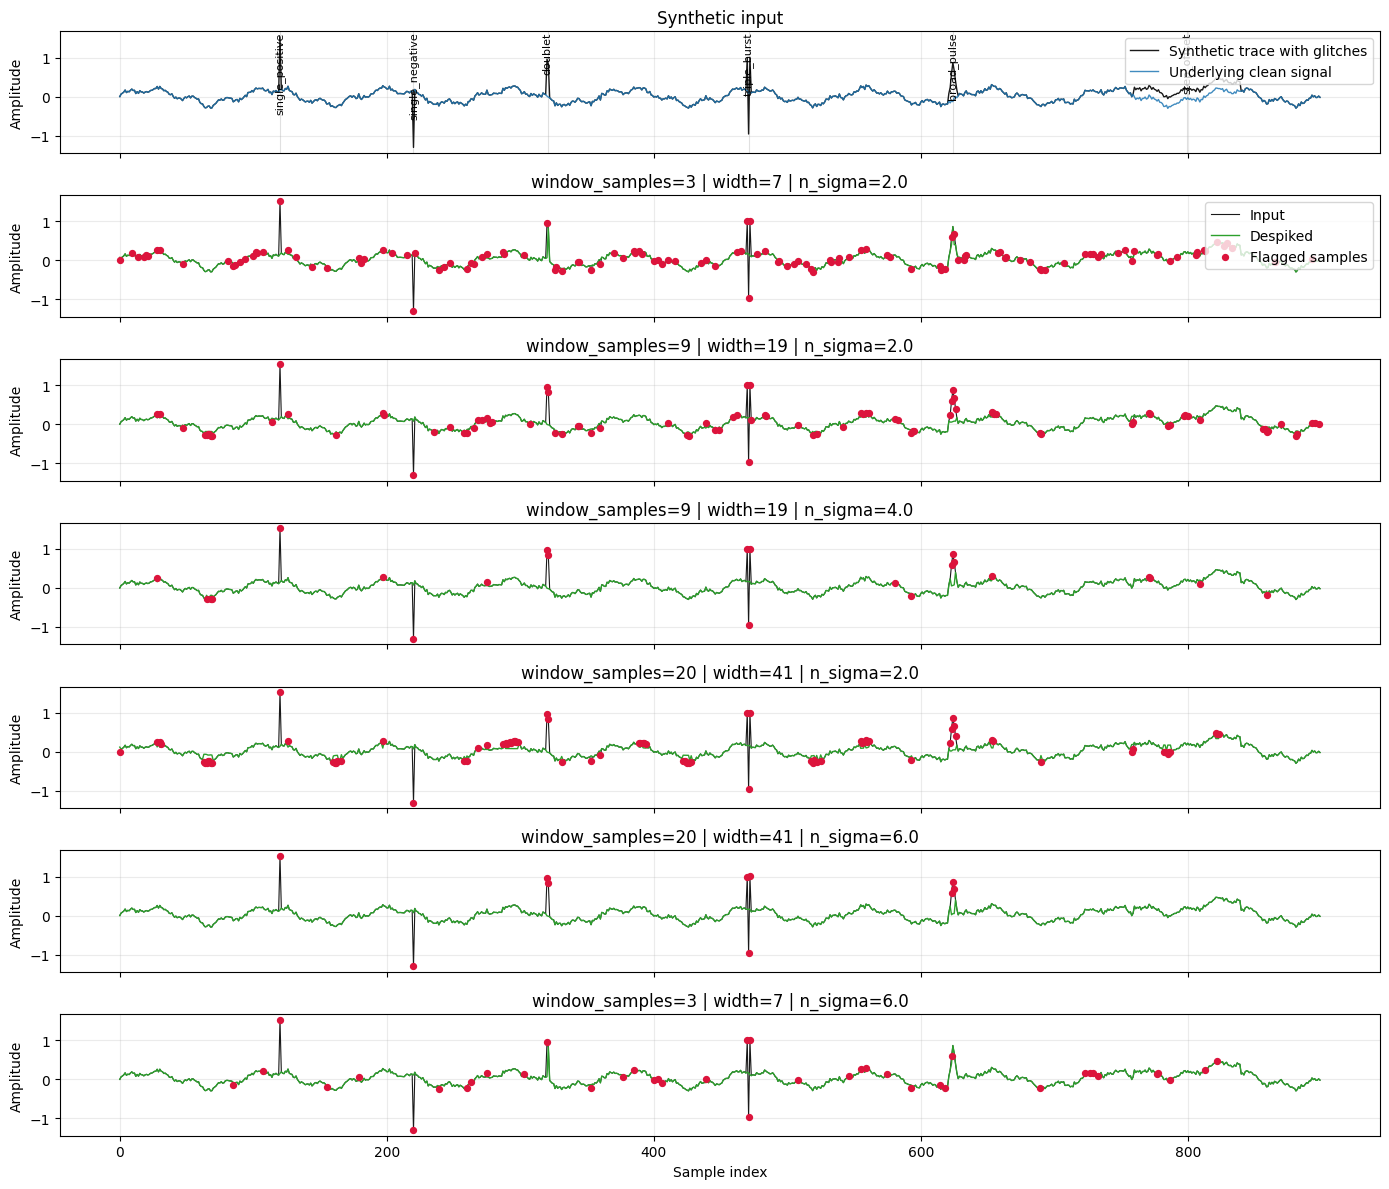

,glitch,glitch_len,flagged_in_glitch,fraction_flagged,window_samples,window_width,n_sigma,total_flagged
0,single_positive,1,1,1.000000,3,7,2.0,131
1,single_negative,1,1,1.000000,3,7,2.0,131
2,doublet,2,1,0.500000,3,7,2.0,131
3,triple_burst,3,3,1.000000,3,7,2.0,131
4,broad_pulse,9,3,0.333333,3,7,2.0,131
5,step_offset,80,13,0.162500,3,7,2.0,131
6,single_positive,1,1,1.000000,9,19,2.0,93
7,single_negative,1,1,1.000000,9,19,2.0,93
8,doublet,2,2,1.000000,9,19,2.0,93
9,triple_burst,3,3,1.000000,9,19,2.0,93


In [14]:
fig, axes = plt.subplots(len(configs) + 1, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t, noisy, color="0.099", lw=1.0, label="Synthetic trace with glitches")
axes[0].plot(t, base, color="tab:blue", lw=1.0, alpha=0.85, label="Underlying clean signal")
axes[0].set_title("Synthetic input")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.25)

for glitch in glitches:
    center = float(np.mean(glitch["indices"]))
    axes[0].axvline(center, color="0.88", lw=0.8, zorder=0)
    y_top = axes[0].get_ylim()[1]
    axes[0].text(center, y_top, glitch["label"], rotation=90, va="top", ha="center", fontsize=8)

summary_frames = []

for ax, cfg in zip(axes[1:], configs):
    trace = SimpleTrace(noisy.copy())
    mask = hampel_despike(trace, **cfg)

    ax.plot(t, noisy, color="0.099", lw=0.8, label="Input")
    ax.plot(t, trace.data, color="tab:green", lw=1.0, label="Despiked")
    ax.scatter(t[mask], noisy[mask], s=18, color="crimson", label="Flagged samples", zorder=3)
    ax.set_ylabel("Amplitude")
    ax.set_title(
        f"window_samples={cfg['window_samples']} | width={2 * cfg['window_samples'] + 1} | n_sigma={cfg['n_sigma']}"
    )
    ax.grid(True, alpha=0.25)

    summary = summarize_detection(mask, glitches)
    summary["window_samples"] = cfg["window_samples"]
    summary["window_width"] = 2 * cfg["window_samples"] + 1
    summary["n_sigma"] = cfg["n_sigma"]
    summary["total_flagged"] = int(mask.sum())
    summary_frames.append(summary)

axes[1].legend(loc="upper right")
axes[-1].set_xlabel("Sample index")
fig.tight_layout()
plt.show()

summary_df = pd.concat(summary_frames, ignore_index=True)
summary_df


In [15]:
focus = summary_df.loc[:, [
    "window_samples",
    "window_width",
    "n_sigma",
    "glitch",
    "glitch_len",
    "flagged_in_glitch",
    "fraction_flagged",
    "total_flagged",
]].copy()

focus_pivot = focus.pivot_table(
    index=["glitch", "glitch_len"],
    columns=["window_samples", "n_sigma"],
    values="flagged_in_glitch",
)

focus_pivot


window_samples                3         9         20     
n_sigma                      2.0  6.0  2.0  4.0  2.0  6.0
glitch          glitch_len                               
broad_pulse     9            3.0  1.0  5.0  3.0  5.0  3.0
doublet         2            1.0  1.0  2.0  2.0  2.0  2.0
single_negative 1            1.0  1.0  1.0  1.0  1.0  1.0
single_positive 1            1.0  1.0  1.0  1.0  1.0  1.0
step_offset     80          13.0  5.0  8.0  3.0  8.0  0.0
triple_burst    3            3.0  3.0  3.0  3.0  3.0  3.0

## How to read the results

- `window_samples=9` means the sample at index `i` is judged against a centered 19-sample neighborhood: `i-9` through `i+9`.
- Increasing `window_samples` makes the local median less sensitive to a narrow glitch, which usually helps catch isolated one-sample spikes.
- If the glitch itself becomes wide relative to the window, the window statistics start to include the glitch and it becomes less likely to be flagged.
- Lowering `n_sigma` makes the filter more aggressive. `n_sigma=2.0` is quite sensitive; `n_sigma=6.0` would be much more conservative.
- In the Apollo notebook, `window_samples=9, n_sigma=2.0` means: use a 19-sample local context and replace any sample that is more than roughly 2 local MAD-based sigmas away from the rolling median.

To experiment, duplicate the `configs` list or change the synthetic glitches and rerun the plotting cell.
